In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_users = pd.read_csv (r"../analytics/data/processed/cleaned_users.csv")
df_loans = pd.read_csv (r"../analytics/data/processed/cleaned_loans.csv")
df_repayments = pd.read_csv (r"../analytics/data/processed/cleaned_repayments.csv")
df_collections = pd.read_csv (r"../analytics/data/processed/cleaned_collections.csv")

print(f"Users: {len(df_users)} rows")
print(f"Loans: {len(df_loans)} rows")
print(f"Repayments: {len(df_repayments)} rows")
print (f"Collections: {len(df_collections)} rows")

Users: 200 rows
Loans: 338 rows
Repayments: 2439 rows
Collections: 404 rows


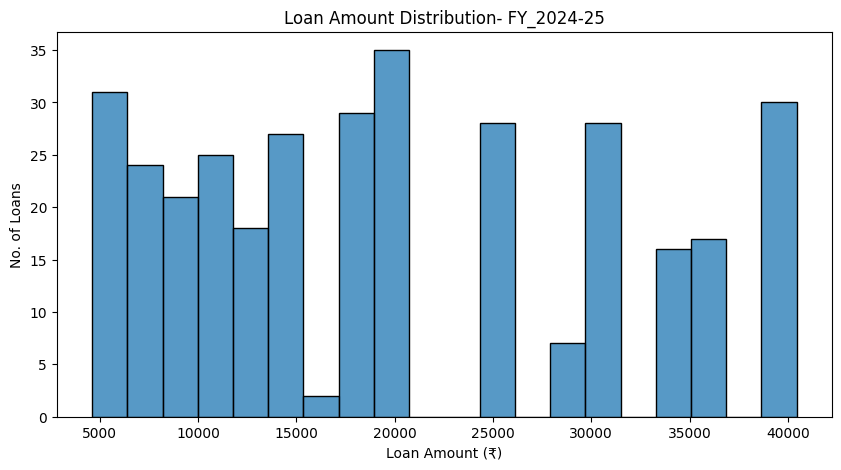

In [7]:
#BRD Q1- Plotting histogram for that question
plt.figure(figsize=(10,5))
sns.histplot (data=df_loans, x='loan_amount', bins=20)
plt.title('Loan Amount Distribution- FY_2024-25')
plt.xlabel('Loan Amount (₹)')
plt.ylabel('No. of Loans')
plt.show()

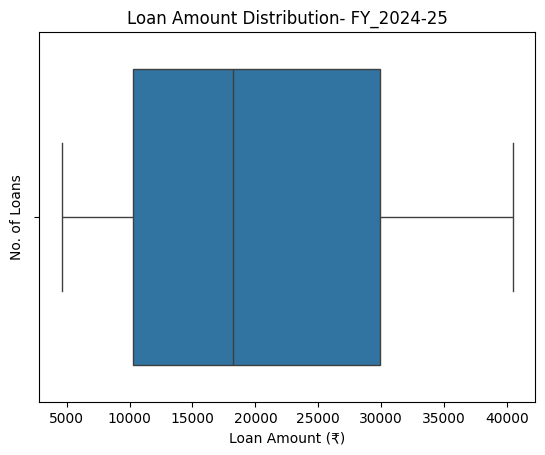

In [8]:
#plotting boxplot for the same

plt.Figure(figsize=(10,4))
sns.boxplot(data=df_loans, x= 'loan_amount')
plt.title('Loan Amount Distribution- FY_2024-25')
plt.xlabel('Loan Amount (₹)')
plt.ylabel('No. of Loans')
plt.show()

In [9]:
# print('collections')
# print(df_collections.head())

# print ("loans")
# print(df_loans.head())

# print('repayments')
# print(df_repayments.head())

# print('users')
# print(df_users.head())

In [10]:
print(df_loans['loan_status'].value_counts())

loan_status
Closed       198
NPA           80
Defaulted     60
Name: count, dtype: int64


In [11]:
bad_loans= df_loans[(df_loans['loan_status'] == 'Defaulted') | (df_loans['loan_status'] =='NPA')]
print( bad_loans.shape)

purpose_defaults = bad_loans['loan_purpose'].value_counts().reset_index()
print(purpose_defaults)

(140, 9)
           loan_purpose  count
0                Travel     27
1  Electronics Purchase     16
2           Home Repair     15
3         Utility Bills     14
4               Wedding     13
5      Business Expense     13
6     Medical Emergency     12
7    Debt Consolidation     12
8        Vehicle Repair      9
9             Education      9


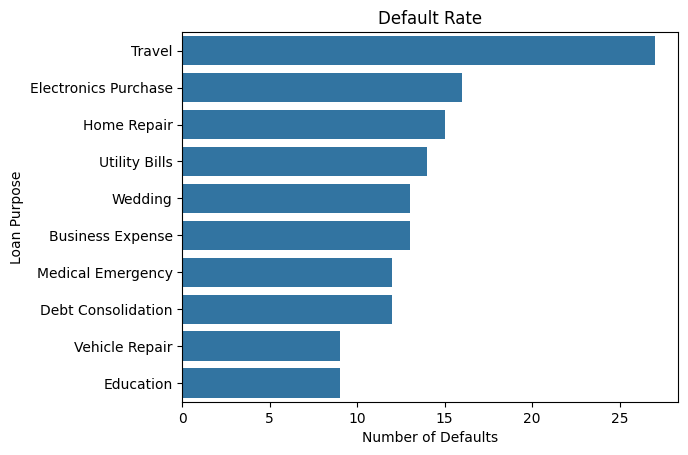

In [12]:
#brd: q2
plt.figure()
sns.barplot(data=purpose_defaults, x='count', y='loan_purpose')
plt.title('Default Rate')
plt.xlabel('Number of Defaults')
plt.ylabel('Loan Purpose')
plt.show()

In [13]:
#brd: q3

merge = pd.merge(bad_loans,df_users, on= 'user_id')
print(merge['city'].value_counts())

city
Bengaluru    28
Hyderabad    25
Delhi        25
Mumbai       21
Pune         19
Kolkata      11
Chennai      11
Name: count, dtype: int64


In [14]:
total_loans = pd.merge(df_loans, df_users, on='user_id')
print(total_loans['city'].value_counts())

city
Mumbai       66
Hyderabad    64
Delhi        63
Bengaluru    60
Pune         38
Chennai      29
Kolkata      18
Name: count, dtype: int64


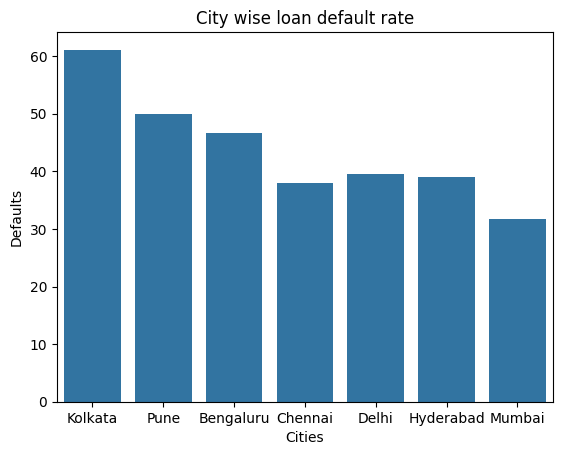

In [15]:
city_default_rate = pd.DataFrame({
    'city': ['Kolkata','Pune','Bengaluru','Chennai','Delhi','Hyderabad','Mumbai'],
    'default_rate': [61.1, 50.0, 46.6, 38.0, 39.6, 39.0, 31.8]
})

plt.figure()
sns.barplot (data=city_default_rate, x='city', y='default_rate')
plt.title('City wise loan default rate')
plt.xlabel ('Cities')
plt.ylabel ('Defaults')
plt.show()

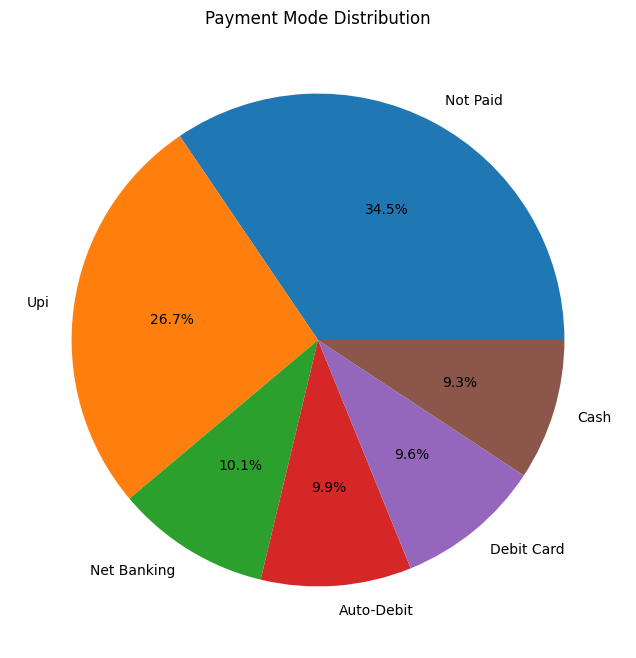

In [16]:
#BRD: Q4

mode= (df_repayments['payment_mode'].value_counts())

plt.figure(figsize=(8,8))
plt.pie(mode.values, labels=mode.index, autopct='%1.1f%%')
plt.title('Payment Mode Distribution')
plt.show()

In [17]:
bad = bad_loans['tenure_months'].value_counts().reset_index().sort_values('tenure_months')
bad.columns = ['tenure_months', 'defaults']
print(bad)

   tenure_months  defaults
1              3        43
0              6        45
3              9        16
2             12        36


In [18]:
total = df_loans['tenure_months'].value_counts().reset_index().sort_values('tenure_months')
total.columns = ['tenure_months', 'total_loans']
print(total)

   tenure_months  total_loans
1              3           96
0              6          105
3              9           45
2             12           92


In [33]:
join= pd.merge(bad, total, on='tenure_months')
join.columns = ['Months', 'Defaults','Loans']
join['default_rate'] = round (join['Defaults'] / join['Loans'] * 100)
print (join)


   Months  Defaults  Loans  default_rate
0       3        43     96          45.0
1       6        45    105          43.0
2       9        16     45          36.0
3      12        36     92          39.0


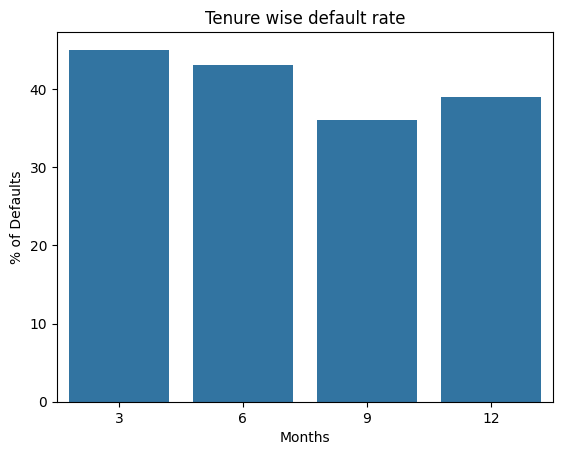

In [37]:
plt.figure()
sns.barplot (data= join, x='Months', y='default_rate')
plt.title('Tenure wise default rate')
plt.xlabel('Months')
plt.ylabel("% of Defaults")
plt.show()